<h1>Outliers</h1>

An outliers is a data point that is abnormally distant from all other observations in your dataset. It is an anomaly that does not fit in pattern.

<h2>Types of outliers</h2>

- Global Outliers: A point far outside the range of entire dataset. (age:150)
- Contextual Outliers: A point that is an anomaly in a specific context, but normal otherwise(eg. 30c is normal in summer, but abnormal in winter)
- Collective outliers: A subset of data points that deviate together as group. (eg. a sudden string of 0 sales for 5 days due to website crash.)

In [1]:
import pandas as pd
import numpy as np

In [2]:
ages = np.random.normal(loc=25,scale=5,size=200)

outliers = np.array([120,150,-10])

data = np.concatenate([ages,outliers])

df = pd.DataFrame({'Age':data})

In [3]:
df

,Age
0,20.400595
1,19.357407
2,25.047007
3,27.142886
4,25.214882
...,...
198,15.426194
199,33.925436
200,120.000000
201,150.000000


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


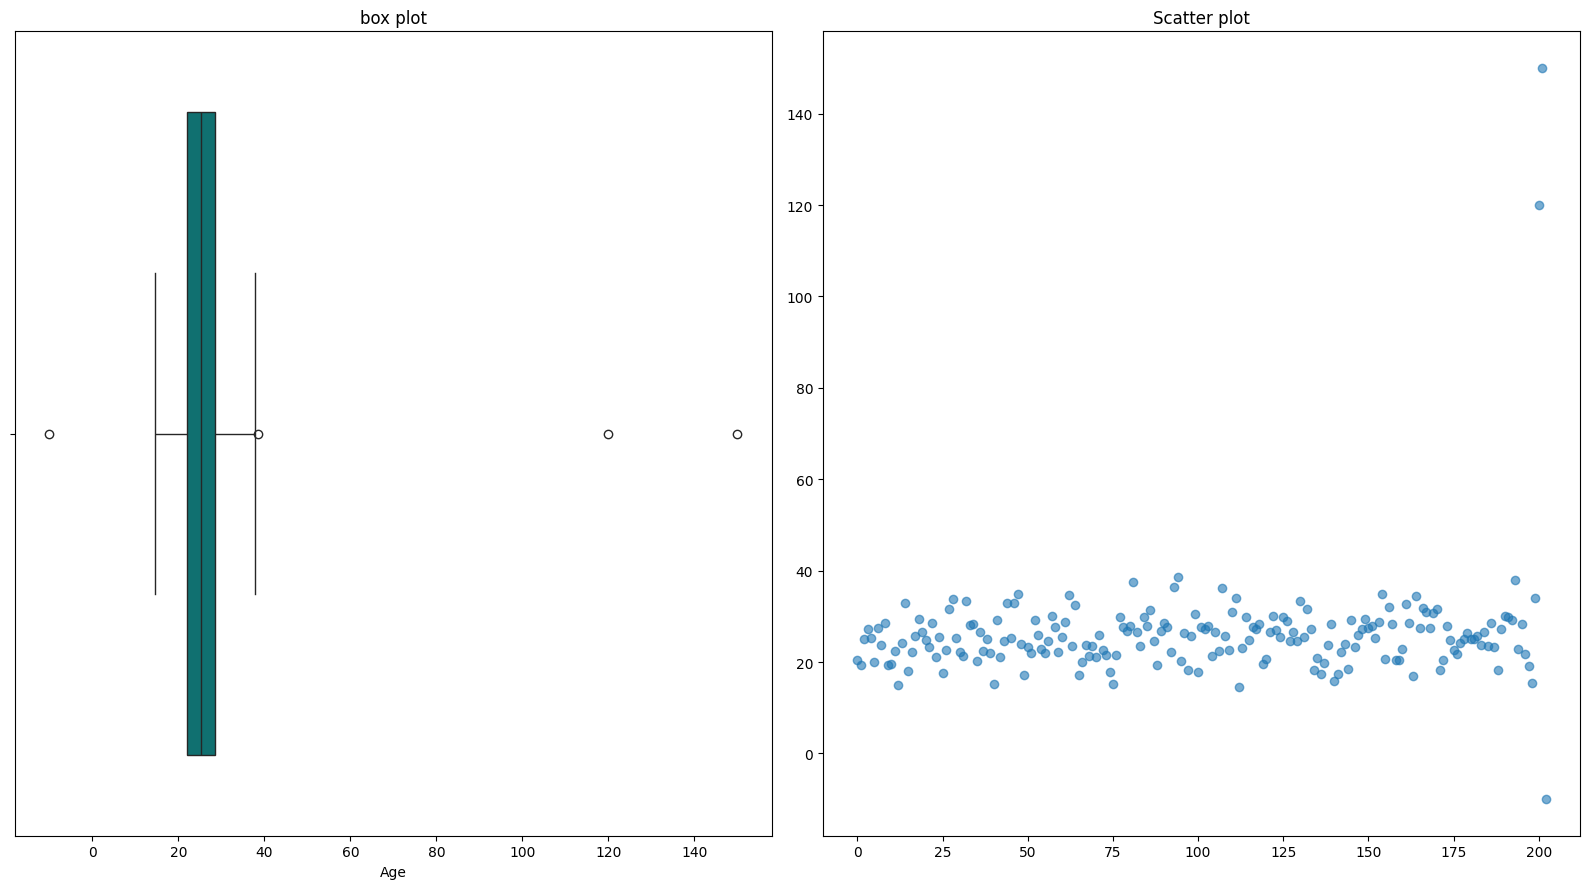

In [9]:
plt.figure(figsize=(16,9))
plt.subplot(1,2,1)
sns.boxplot(x=df['Age'],color='teal')
plt.title("box plot")

plt.subplot(1,2,2)
plt.scatter(range(len(df)),df['Age'],alpha=0.6)
plt.title("Scatter plot")

plt.tight_layout()
plt.show()

<h2>Detect Outliers(IQR(Inter quartile range) Method)</h2>

In [11]:
#calculate = Q1 (25 percentile) and Q3 (75 percentile)
#IQR = Q3 - Q1

Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

In [12]:
print(IQR)

6.613202760867257


lower bound = Q1 - 1.5 x IQR

upper bound = Q3 + 1.5 x IQR

In [14]:
lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

In [15]:
print(lower_bound,upper_bound)

11.986458238343273 38.4392692818123


Capping

In [18]:
df['Age_capping'] = np.where(df['Age']>upper_bound,upper_bound,np.where(df['Age']<lower_bound,lower_bound,df['Age']))

In [21]:
df.tail(50)

,Age,Age_capping
153,28.697861,28.697861
154,34.867091,34.867091
155,20.634854,20.634854
156,32.014557,32.014557
157,28.309198,28.309198
158,20.403087,20.403087
159,20.451987,20.451987
160,22.912836,22.912836
161,32.622095,32.622095
162,28.650485,28.650485


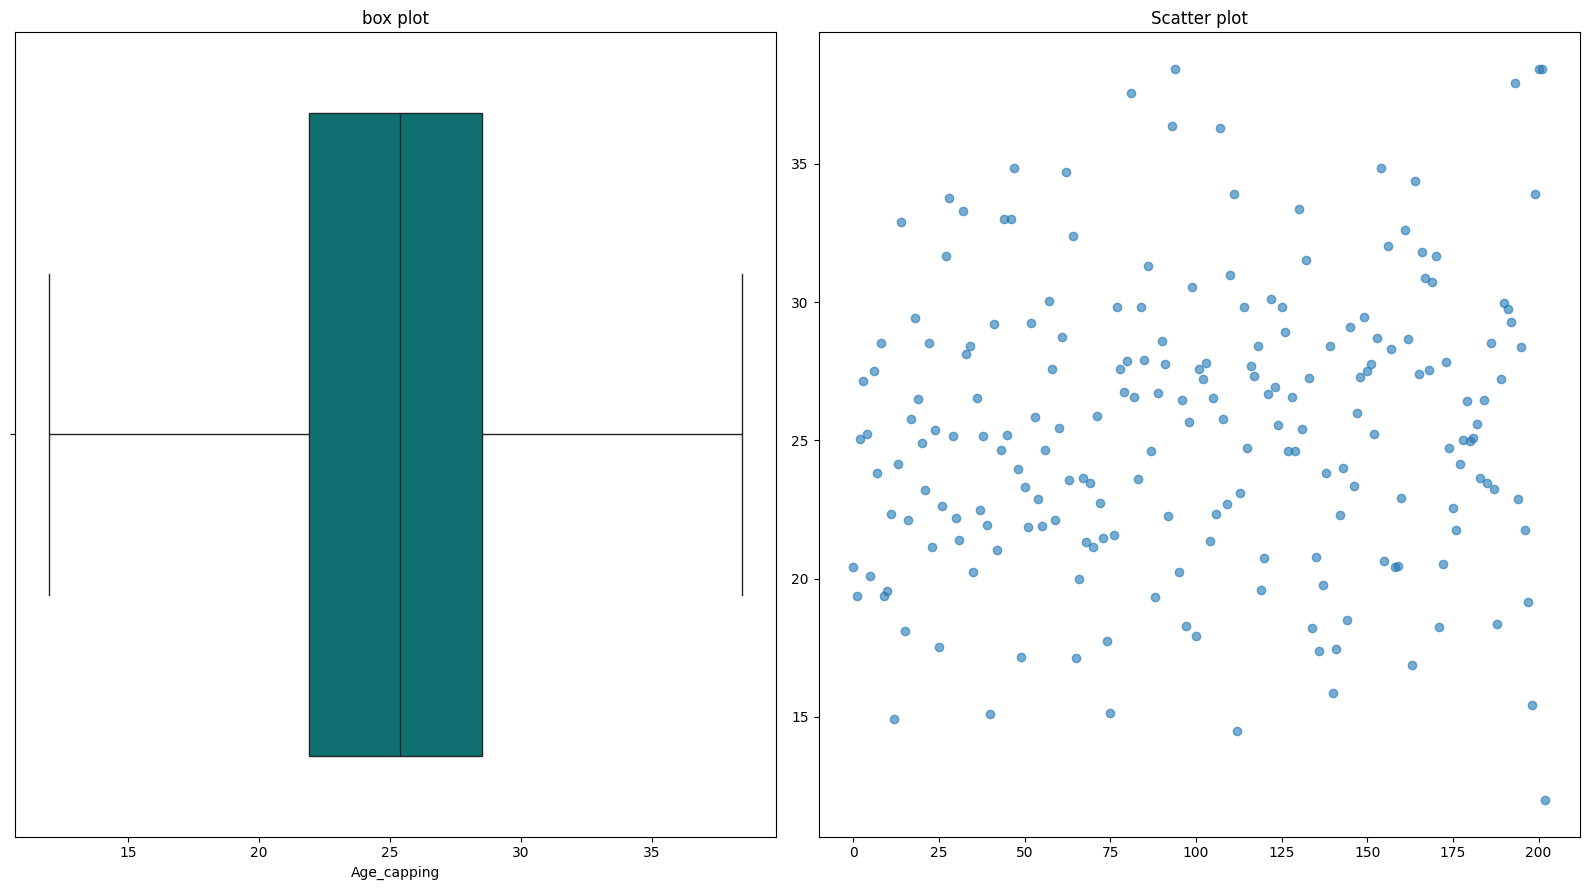

In [22]:
plt.figure(figsize=(16,9))
plt.subplot(1,2,1)
sns.boxplot(x=df['Age_capping'],color='teal')
plt.title("box plot")

plt.subplot(1,2,2)
plt.scatter(range(len(df)),df['Age_capping'],alpha=0.6)
plt.title("Scatter plot")

plt.tight_layout()
plt.show()

<h2>Z-score</h2>

In [23]:
from scipy.stats import zscore

In [24]:
np.random.seed(42)

x = np.random.normal(loc=120,scale=10,size=200)

outliers = np.array([190,50,250])

data = np.concatenate([x,outliers])
df = pd.DataFrame({"X":data})

df.tail(20)

,X
183,124.824724
184,117.765372
185,127.140005
186,124.732376
187,119.271711
188,111.532063
189,104.851528
190,115.534850
191,128.563988
192,122.140937


In [25]:
df['z_score'] = zscore(df['X'])

In [26]:
df.tail(10)

,X,z_score
193,107.542612,-0.862657
194,121.731809,0.101451
195,123.853174,0.245591
196,111.161426,-0.616771
197,121.537251,0.088232
198,120.582087,0.023331
199,108.570297,-0.792829
200,190.000000,4.740045
201,50.000000,-4.772484
202,250.000000,8.816843


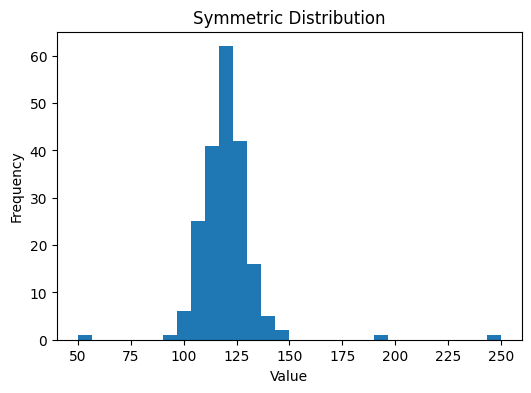

In [27]:
plt.figure(figsize=(6,4))
plt.hist(df['X'],bins=30)
plt.title("Symmetric Distribution")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

Thresh value should be 3 or -3

In [28]:
thres = 3
outliers_detected = df[(df['z_score']>thres) | (df['z_score']< -thres)]

In [29]:
outliers_detected

,X,z_score
200,190.0,4.740045
201,50.0,-4.772484
202,250.0,8.816843
